The goal of this notebook is to see how the absolute error ( $|p-\hat{p}|$ ) varies with the number of shots taken from the optimized QSP circuit.

In [1]:
from QSP_PE import QSP_PE
from single_iteration import QSP_single_iteration
import matplotlib.pyplot as plt
import numpy as np
from estimateP import estimate_p_bisect, estimate_p_bisect_baseline
from noise_signal_design import optimize_noise_sensitivity, baseline, initial_state_baseline
from single_iteration import *

In [2]:
zero = np.array([1, 0], dtype=complex)
rho = np.outer(zero, zero.conj().T)

p_real = 0.01
p_prev = 0.015
dk = 16
C = 5
q = 2
rk_prev = 0.01
mk = [500, 1000, 2000, 4000, 8000, 16000]

In [3]:
def QSP_single_iteration_num_shots(mk, C, dk, rk_prev, q, p_real, p_prev, rho):
    theta, Phi, L_E, kappa = optimize_noise_sensitivity(d=dk, p_lo=p_prev-rk_prev, p_hi=p_prev+rk_prev)
    rho = build_rho(theta, Phi, p_real, rho)
    prob0 = float(np.clip(rho[0,0].real, 0.0, 1.0))
    overall = []
    stds = []
    for m in mk:
        results = np.zeros(100)
        for i in range(100):
            X = np.random.choice([0, 1], size=m, p=[1-prob0, prob0])
            p_hat = estimate_p_bisect(theta, Phi, X, p_prev-rk_prev, p_prev+rk_prev)
            error = np.abs(p_real-p_hat)
            results[i] = error
        overall.append(np.mean(results))
        stds.append(np.std(results))
    return overall, stds

overall, stds = QSP_single_iteration_num_shots(mk=mk, C=C, dk=dk, rk_prev=rk_prev, q=q, p_real=p_real, p_prev=p_prev, rho=rho)

L_E = 1.1705 theta = 0.3000
L_E = 2.2881 theta = 0.4604
L_E = 6.0688 theta = 0.4118
L_E = 1.4046 theta = 0.1623
L_E = 8.0974 theta = 0.3309
L_E = 16.1423 theta = 0.3963
L_E = 5.0878 theta = 0.4967
L_E = 16.1039 theta = 0.4081
L_E = 16.9416 theta = 0.4023
L_E = 16.8829 theta = 0.3729
L_E = 17.4444 theta = 0.3882
L_E = 17.4788 theta = 0.3876
L_E = 17.7220 theta = 0.3845
L_E = 18.1069 theta = 0.3770
L_E = 18.2899 theta = 0.3712
L_E = 18.5838 theta = 0.3729
L_E = 18.9581 theta = 0.3825
L_E = 19.3559 theta = 0.3841
L_E = 20.0485 theta = 0.3885
L_E = 20.6187 theta = 0.3756
L_E = 20.6802 theta = 0.3726
L_E = 20.7839 theta = 0.3716
L_E = 20.9936 theta = 0.3736
L_E = 21.1651 theta = 0.3798
L_E = 21.4079 theta = 0.3977
outer step   0  L_E = 21.4079  theta = 0.3977
L_E = 21.4079 theta = 0.3977
L_E = 20.7317 theta = 0.4495
L_E = 21.5369 theta = 0.4158
L_E = 21.5353 theta = 0.4248
L_E = 21.5507 theta = 0.4204
L_E = 21.5704 theta = 0.4320
L_E = 21.6049 theta = 0.4352
L_E = 21.7189 theta = 0.4542
L_E

In [11]:
one = np.array([0, 1], dtype=complex)
rho0 = np.outer(one, one.conj().T)

def QSP_single_iteration_num_shots(mk, C, dk, rk_prev, q, p_real, p_prev, rho0):
    theta, Phi, L_E, kappa = baseline(d=dk, p_lo=p_prev-rk_prev, p_hi=p_prev+rk_prev)
    rho = build_rho(theta, Phi, p_real, rho0)
    prob0 = float(np.clip(rho[0,0].real, 0.0, 1.0))
    overall = []
    stds = []
    for m in mk:
        results = np.zeros(100)
        for i in range(100):
            X = np.random.choice([0, 1], size=m, p=[1-prob0, prob0])
            p_hat = estimate_p_bisect_baseline(theta, Phi, X, p_prev-rk_prev, p_prev+rk_prev, rho0)
            error = np.abs(p_real-p_hat)
            results[i] = error
        overall.append(np.mean(results))
        stds.append(np.std(results))
    return overall, stds

overall_base, stds_base = QSP_single_iteration_num_shots(mk=mk, C=C, dk=dk, rk_prev=rk_prev, q=q, p_real=p_real, p_prev=p_prev, rho0=rho0)

Baseline: L_E = 23.2209  theta = 0.0000


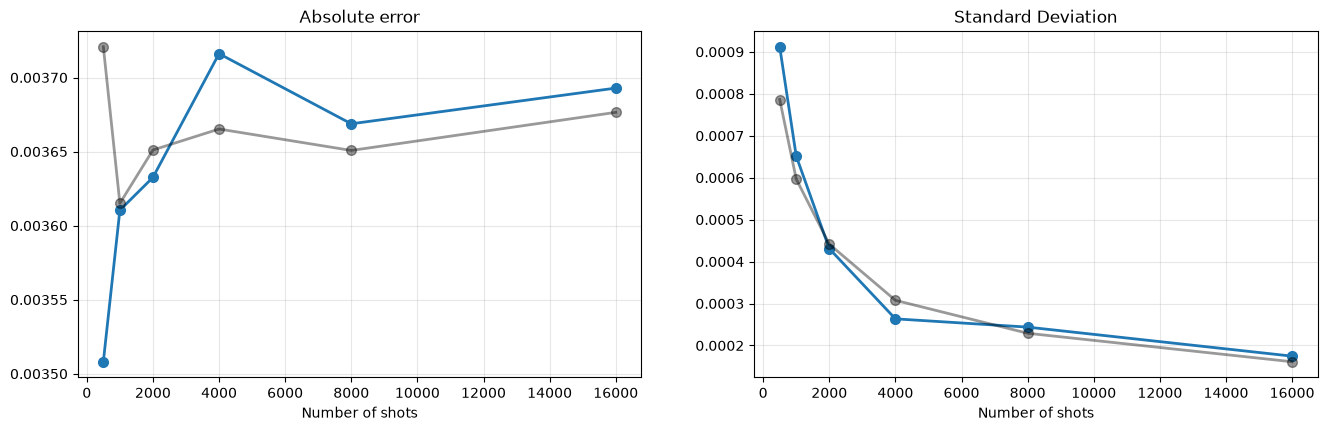

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(16, 4.5))
axs[0].plot(mk, overall, "o-", lw=2, markersize=7)
axs[0].plot(mk, overall_base, "ko-", alpha=0.4, lw=2, markersize=7)
axs[0].set_xlabel('Number of shots')
axs[0].set_title('Absolute error')
axs[0].grid(True, alpha=0.3)

axs[1].plot(mk, stds, "o-", lw=2, markersize=7)
axs[1].plot(mk, stds_base, "ko-", alpha=0.4, lw=2, markersize=7)
axs[1].set_xlabel('Number of shots')
axs[1].set_title('Standard Deviation')
axs[1].grid(True, alpha=0.3)

plt.show()